## MACHINE LEARNING NOTEBOOK

#### This notebook aims to :
1. **Predict Customer Conversion:** Build a binary classification model to accurately predict whether an online shopping session will result in revenue (a purchase) or not.

2. **Identify Key Behavioral Drivers:** Analyze feature importances to determine which browsing metrics  impact a user's decision to buy the most.

3. **Optimize Model Performance:** Evaluate the model using precision, recall, and F1-score to ensure it handles the imbalanced nature of the dataset effectively and minimizes false positives.

### Importing necessary libraries

In [1]:
# 1. Standard Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization (for evaluating our model later)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn Machine Learning Ecosystem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Loading the cleaned dataset 

In [9]:
# Read the CSV file
df = pd.read_csv('online_shoppers_intention.csv')

# checking to ensure rows and columns loaded correctly
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 12330 rows and 18 columns.


## Data preprocessing

In [14]:
# 1. Isolate the target variable (Revenue) and convert True/False to 1/0
## True =1 and false = 0
y = df['Revenue'].astype(int)

# 2. Isolating the predictor features
X_raw = df.drop('Revenue', axis=1)

# 3. Convert categorical columns into numerical dummy variables
X = pd.get_dummies(X_raw, drop_first=True,dtype = int)

# 4. Preview the fully numerical features dataframe
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


## Data Splitting and handling imbalance
 * From the data analysis, it shows the ratio of purchases to non purchases is 10422:1908 
 * This is about 0.85:0.15. The imbalance needs to be attended to


In [15]:
# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,       # 20% allocated to testing
    random_state=42,      # Ensures reproducible results every time you run it
    stratify=y            # Keeps the 15% vs 85% purchase ratio identical in both sets...
)

print(f"Training set size: {X_train.shape[0]} sessions")
print(f"Testing set size: {X_test.shape[0]} sessions")

Training set size: 9864 sessions
Testing set size: 2466 sessions


### Model Training (Random Forest)

In [16]:
# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# 2. Fit the model using only the training data
rf_model.fit(X_train, y_train)

print("Random Forest Model has been trained successfully!")

Random Forest Model has been trained successfully!


### Model Evaluation

=================== MODEL PERFORMANCE ===================
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.54      0.62       382

    accuracy                           0.90      2466
   macro avg       0.83      0.75      0.78      2466
weighted avg       0.89      0.90      0.89      2466



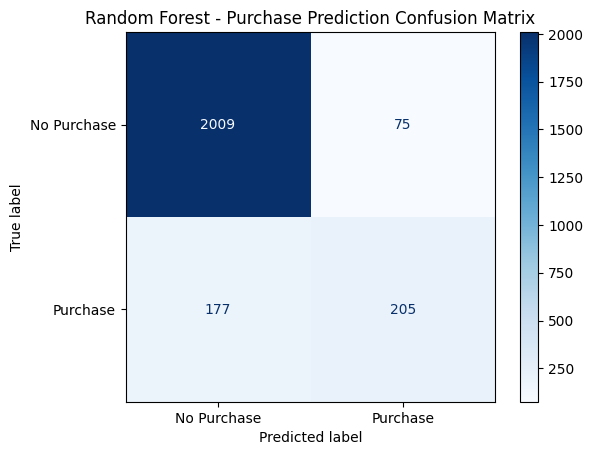

In [18]:
# 1. Generate predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# 2. Print out the formal Classification Report (Precision, Recall, F1-Score)
print("=================== MODEL PERFORMANCE ===================")
print(classification_report(y_test, y_pred))

# 3. Generate and plot a visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(cmap='Blues')

plt.title("Random Forest - Purchase Prediction Confusion Matrix")
plt.show()

C:\Users\Babji\AppData\Local\Temp\ipykernel_7276\3596798826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


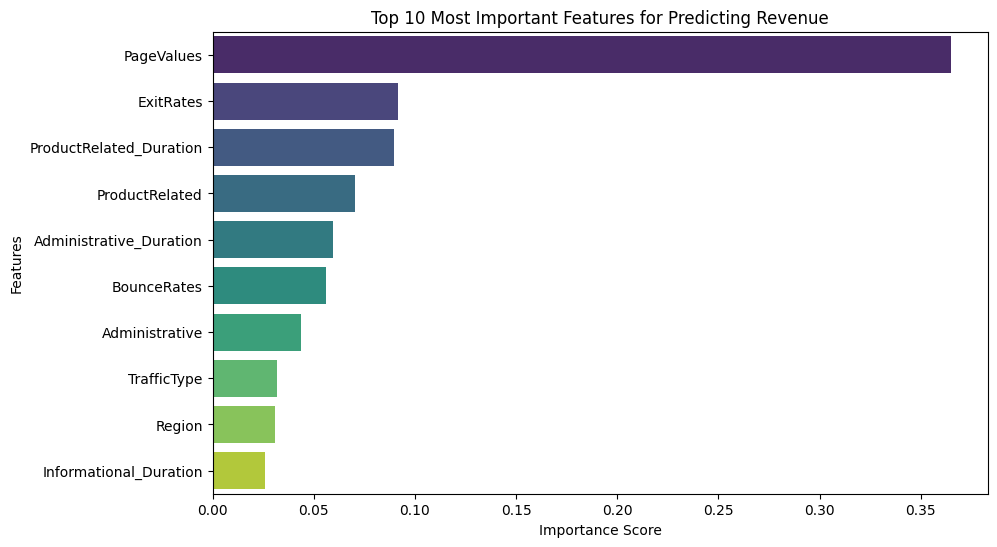

In [20]:
# Extract feature importances from your trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a clean DataFrame to display them
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Revenue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()